# **Feature Scaling**

Feature scaling is a vital pre processing step in machine learning that involves transforming numerical features to a common scale.


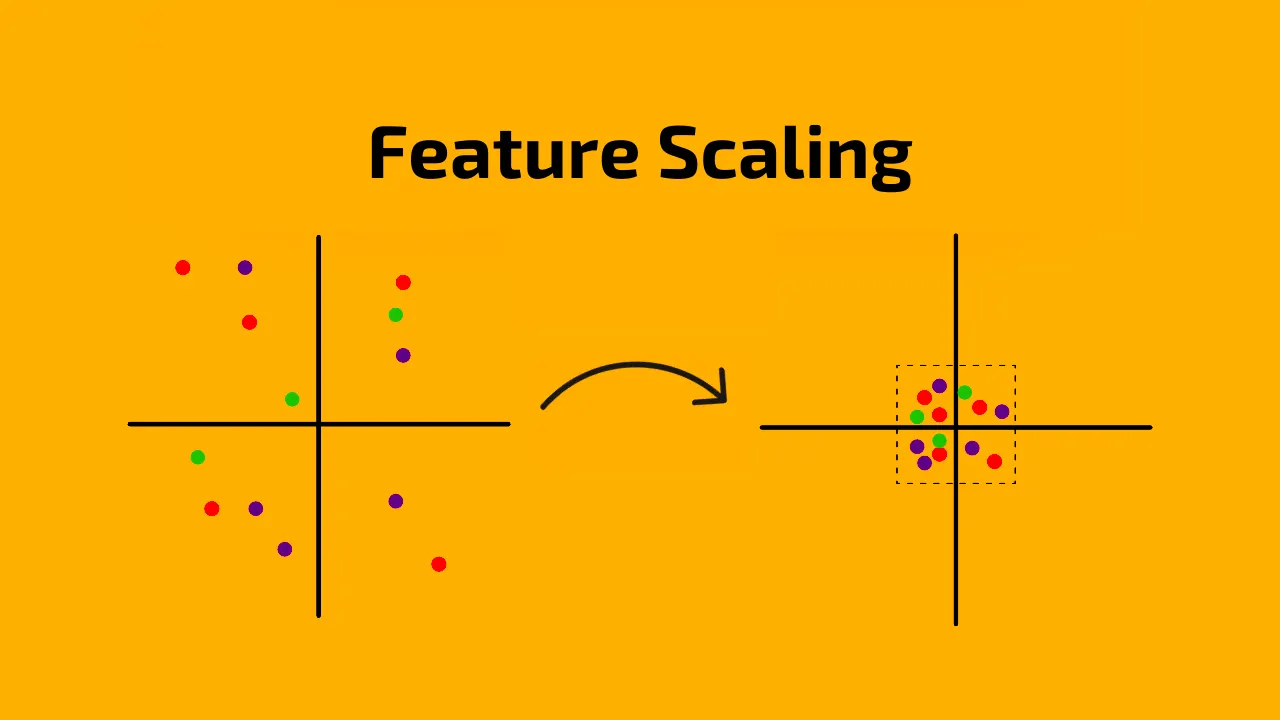

## **Why Do We Need Feature Scaling?**

Machine learning algorithms do not automatically handle differences in feature scales.

* **Distance-Based Models Require Scaling**
  - Many ML algorithms use distance-based calculations to make predictions such as K-nearest neighbors.

  - If one feature has a larger range, it will dominate the distance metric.

    Example:

    - Income (0–100,000)
    - Age (0–100)

    Income would overpower age in distance calculations.

    👉 **In models like KNN, scaling is necessary, not optional.**






* **Faster Convergence in Gradient Descent**
  - Gradient descent updates model weights using feature values.
  - If features have very different scales:

    - Large-scale features dominate updates
    - Small-scale features update very slowly
    - Optimization becomes inefficient
    - Convergence takes longer

    <br>

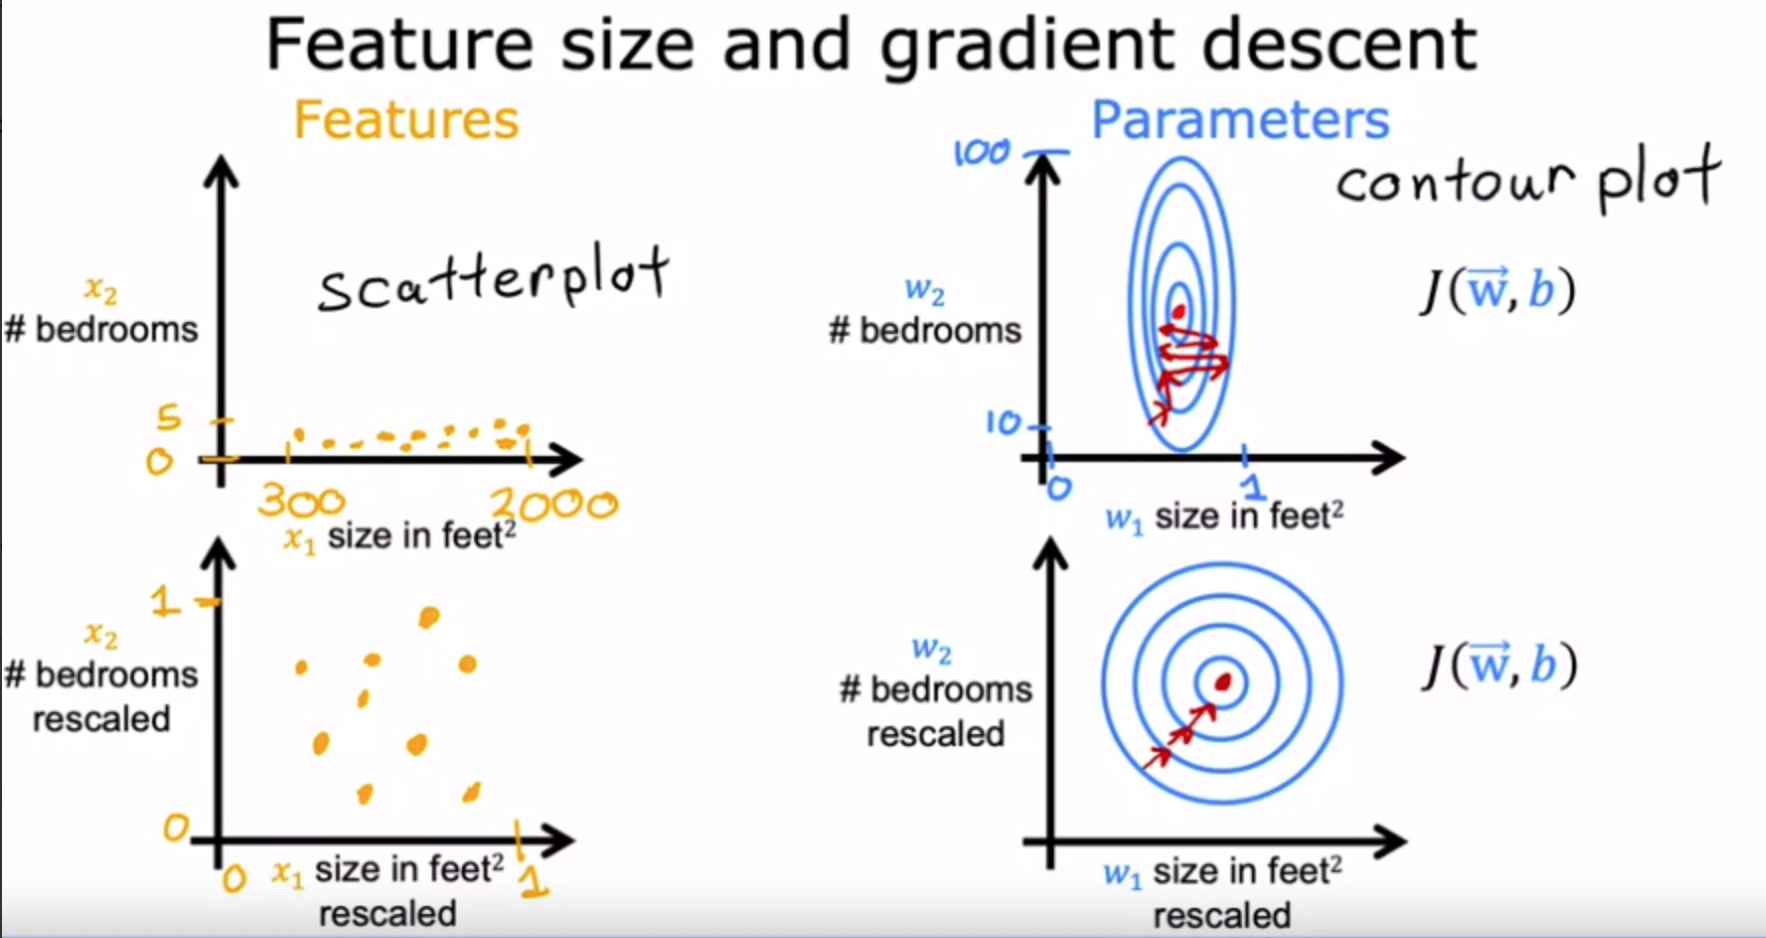

## **When Scaling Is NOT Necessary**

Tree-based models do not require scaling:

- Decision Trees
- Random Forest
- ...

**Why?** These models split based on feature thresholds, not distances or gradient-based optimization.

> Add blockquote



So scaling does not affect their performance.

## **Comparing Model Coefficients**

Scaling also helps us compare feature importance.

If all features are on the same scale:

- Coefficients become directly comparable.

However, there is a trade-off:

| Benefit                        | Drawback                                           |
| ------------------------------ | -------------------------------------------------- |
| Easier to compare coefficients | Harder to interpret coefficients in original units |

After scaling:

- A "one unit increase" is no longer in original measurement.
- It refers to a scaled unit.

<br><br>

## **Two Main Types of Feature Scaling**

There are many methods, but the two most common are:

### **1. Standardization (Z-score Scaling)**

Transforms data to:

- Mean (μ) = 0  
- Standard deviation (σ) = 1  

**Formula:**

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

**Steps:**

- Compute mean  
- Compute standard deviation  
- Subtract mean  
- Divide by standard deviation  

⚠ **Important:**  
Standardization is sometimes called Z-score normalization.  
People often say "normalization" when they really mean standardization.

Standardization can produce negative values.


<br>



### **2. Normalization (Min-Max Scaling)**

Scales values between 0 and 1.

**Formula:**

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Steps:**

- Find minimum  
- Find maximum  
- Subtract minimum  
- Divide by range  

**Result:**  
All values fall between 0 and 1.

<br><br>

### **When to Use Each Scaling Method**

#### **Use Standardization (Z-score Scaling) when:**

- **The model uses gradient descent**

  Examples:
  - Linear Regression (with Gradient Descent)
  - Logistic Regression
  - Neural Networks
  - Support Vector Machines

  Why?  
  These models optimize using gradients. Standardization centers data around 0, which helps gradients behave more smoothly and converge faster.

- **The data is approximately normally distributed**

  If features resemble a bell-shaped distribution, standardization preserves that structure.

- **You expect outliers**

  Standardization is less sensitive to outliers than Min-Max scaling because it does not compress everything into a strict 0–1 range.

- **You want features centered around zero**

  Some algorithms (especially SVM and PCA) perform better when features are centered.

<br>

#### **Use Normalization (Min-Max Scaling) when:**

  - **You need values in a bounded range (0–1)**

    Examples:
    - Neural networks with sigmoid activation
    - Image pixel scaling
    - Algorithms that require bounded inputs

- **You care about relative scale within a fixed range**

  Min-Max keeps the smallest value at 0 and largest at 1, preserving proportional relationships.

- **The data does NOT contain extreme outliers**

  Min-Max scaling is very sensitive to outliers. A single extreme value will compress the rest of the data.

<br>

#### 🎯 **Practical Rule of Thumb**

- If unsure → Use Standardization (more generally applicable)
- If model requires bounded input → Use Normalization
- If there are strong outliers → Prefer Standardization
- For deep learning image data → Min-Max scaling is common

<br>

## **Fit vs Transform (Very Important!)**

When using scaling in libraries like Scikit-Learn, we use:

- `fit()`
- `transform()`
- `fit_transform()`


#### **What Does `fit()` Do?**

  It calculates necessary statistics:

  - Standardization → mean and standard deviation  
  - Normalization → min and max  

  It does **NOT** change data.



#### **What Does `transform()` Do?**

  It applies the scaling formula using the statistics computed during `fit()`.



#### ⚠️ **Critical Rule: Avoid Data Leakage**

  We must:

  - Split into train and test sets first  
  - Fit only on the training data  
  - Transform both training and test data  



#### **Correct Workflow:**

  - Train/Test Split  
  - Fit scaler on `X_train`  
  - Transform `X_train`  
  - Transform `X_test`  

  🚫 **Never fit on the entire dataset.**



##### **Why?**

  If you calculate mean, min, or max using the full dataset, you are using information from the test set.

  This causes **data leakage**.

  **Data leakage means:**  
  Your model indirectly sees information from the test set during training.

  This leads to:

  - Overly optimistic performance  
  - Poor real-world generalization  

<br>

## **Should We Scale the Target Variable (Y)?**

Generally, **No**.

#### **Reasons:**

  - Scaling Y changes the meaning of the prediction.  
  - You're altering the real-world interpretation.  
  - It may negatively affect gradient descent.  

We typically only scale the feature matrix **X**.

<br>





## **Order of Operations: Polynomial Features and Scaling**

When working with polynomial features and feature scaling, the correct sequence is crucial to avoid data leakage and maintain meaningful feature relationships.

**Always apply polynomial feature generation *before* feature scaling.**

**Why?**

1.  **New Feature Creation:** Polynomial features (e.g., `x^2`, `x*y`) are derived from the *original* feature values. Generating these from unscaled data ensures their mathematical relationships are preserved.
2.  **Consistent Scaling:** Scaling is applied to the *entire set* of features (original + polynomial) once they are all created. This ensures all features are brought to a comparable scale.
3.  **Data Leakage Prevention:** Just like with regular features, the scaler should *only* be fitted on the training data after polynomial features have been generated. Then, both training and test sets (with polynomial features) are transformed using that fitted scaler.

<br><br>

## **Does Scaling Harm Data Information or Relationships?**

A common concern is that feature scaling might 'ruin' information or 'damage' relationships within the data. This is generally **not the case** when scaling is applied correctly.

Here's why:

1.  **Preserves Information:** Most scaling methods (like Standardization and Normalization) are **linear transformations**. This means they only shift and/or stretch/compress the data. They do not change the *order* of data points, the *relative distances* proportionally within a feature, or the *shape* of the distribution. The inherent patterns and structures are preserved.

2.  **Maintains Feature Relationships:** The **correlation** between any two features remains unchanged after linear scaling. If Feature A and Feature B are positively correlated, they will remain positively correlated after scaling. Scaling only affects their magnitudes, not their statistical association.

3.  **Maintains Feature-Target Relationships:** Crucially, scaling **does not alter the relationship between your features (X) and the target variable (Y)**. If a feature has a linear relationship with the target, it will still have that linear relationship after scaling; the coefficients might change due to the new scale, but the predictive power derived from that relationship remains. For non-linear relationships, scaling also preserves these structural dependencies.

4.  **Benefits Models:** Instead of damaging models, scaling often *improves* them by:
    *   **Faster Convergence:** Helping gradient descent-based algorithms converge more quickly and efficiently.
    *   **Fairness:** Ensuring all features contribute proportionally in distance-based algorithms.
    *   **Effective Regularization:** Allowing regularization techniques to apply penalties fairly across all features.
    *   **No Harm to Tree-based Models:** These models are unaffected by scaling, so there's no downside here.

In essence, scaling transforms the data's representation but preserves its fundamental informational content and the relationships critical for model learning.

<br><br>

## **Scaling in Production: Common Issues & Considerations**

When you deploy a machine learning model, it will encounter new, unseen data. It's crucial to apply scaling consistently to this new data.

### **1. Handling New Data (Post-Deployment)**

**Issue:** If new data comes in, how should it be scaled?

**Solution:** You **must use the *exact same scaler* that was `fit()` on your *training data*** during the model's development. You should never re-fit the scaler on new data or scale new data independently.

**Why?**
*   **Consistency:** The model learned patterns based on features transformed by a specific mean/std (for `StandardScaler`) or min/max (for `MinMaxScaler`). To ensure the model interprets new data in the same way, it must be transformed using the *same reference points*.
*   **Data Leakage Prevention:** Re-fitting the scaler on new data would introduce information about the current (potentially unrepresentative) batch of new data into your scaling parameters, which could lead to inconsistent transformations over time.


### **2. Reverse Scaling (Inverse Transform)**

**Issue:** Do we ever need to convert scaled predictions back to their original scale?

**Scenario: Yes, this happens frequently! While typically `Y` (the target variable) is *not* scaled, there are specific situations where scaling `Y` can be beneficial for model training.** In such cases, if your model outputs predictions in a scaled space, you will definitely need to convert those predictions back to the original scale for interpretability and real-world use.

**Common Scenarios for Scaling the Target Variable (Y):**

*   **Highly Skewed Target Distributions:** If your target variable has a very skewed distribution (e.g., highly positive values for income, housing prices, or certain chemical concentrations), applying a **log transformation** (which is a form of scaling) can make its distribution more Gaussian-like. Many models, especially linear ones or some neural networks, perform better when the target variable is more normally distributed.
*   **Neural Networks with Specific Activation Functions:** Some neural network architectures or activation functions (e.g., `tanh` which outputs values between -1 and 1, or `sigmoid` for 0-1 output) might perform more stably or efficiently if the target variable is scaled to match their output range.
*   **Improving Model Stability/Convergence:** In some complex models or challenging datasets, scaling the target variable can contribute to overall numerical stability during the optimization process, similar to how scaling features helps.
*   **Preventing Outlier Domination:** If `Y` has extreme outliers, scaling it can prevent these outliers from overly dominating the loss function during training, especially with mean squared error (MSE) based objectives.

**Example Case:**
*   Imagine you are building a **regression model to predict house prices**. The raw prices can range from tens of thousands to millions. If you apply a **log transformation** to these prices (e.g., `log(price)`) to make their distribution more normal, your model will then predict `log(price)`. To tell a client, 'this house is predicted to cost $X', you must `inverse_transform` (e.g., `exp(log(price))`) the model's output back to the original price scale.
*   Another example is **forecasting stock prices**. If the raw stock prices have a very large range and you scale them (e.g., with `MinMaxScaler` to 0-1) before training your forecasting model, the model's predictions will be in the 0-1 range. To communicate actual predicted stock values, you'd need to apply the `inverse_transform` of that `MinMaxScaler`.

**Solution:** Most `sklearn` scalers provide an `inverse_transform()` method. This allows you to present your model's output in the original, meaningful units to stakeholders.

**Workflow for Reverse Scaling:**
```python
# Assuming `scaled_predictions` are your model's output and `y_scaler` was used to scale the target
original_predictions = y_scaler.inverse_transform(scaled_predictions)
```

<br>

Note:  **There is virtually no downside.**

If unsure whether to scale — scale anyway.

It’s computationally cheap and rarely harmful.

<br>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create dataset
data = {
    "Hours_Studied": [105,101,60,70,76,120,104,108,100,30],
    "Attendance":    [10,5,3,6,3,7,8,9,2,6],
    "Pass":          [99,81,54,76,80,98,93,99,45,20]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Attendance,Pass
0,105,10,99
1,101,5,81
2,60,3,54
3,70,6,76
4,76,3,80
5,120,7,98
6,104,8,93
7,108,9,99
8,100,2,45
9,30,6,20


In [3]:
X = df.drop("Pass", axis=1)
y = df["Pass"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ============================
# STANDARDIZATION
# ============================

scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Alternatively (safe because it’s applied only to training set)
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


# ============================
# NORMALIZATION (Min-Max)
# ============================

minmax_scaler = MinMaxScaler()

# Fit only on training data
minmax_scaler.fit(X_train)

# Transform both training and test data
X_train_norm = minmax_scaler.transform(X_train)
X_test_norm = minmax_scaler.transform(X_test)



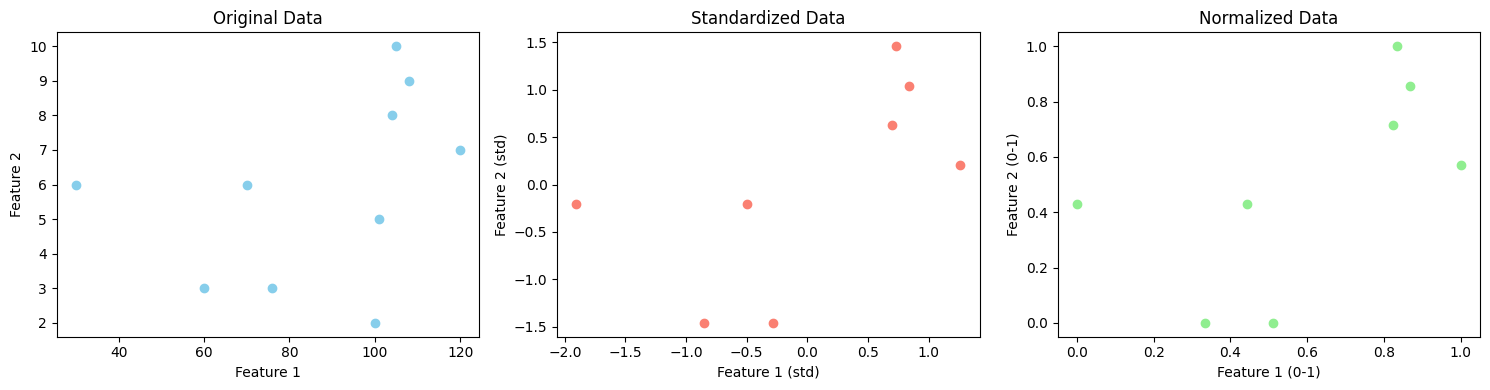

In [6]:
import matplotlib.pyplot as plt

# -----------------------------
# Plotting Before and After Scaling
# -----------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X["Hours_Studied"], X["Attendance"], color='skyblue')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1,3,2)
plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], color='salmon')
plt.title("Standardized Data")
plt.xlabel("Feature 1 (std)")
plt.ylabel("Feature 2 (std)")

plt.subplot(1,3,3)
plt.scatter(X_train_norm[:,0], X_train_norm[:,1], color='lightgreen')
plt.title("Normalized Data")
plt.xlabel("Feature 1 (0-1)")
plt.ylabel("Feature 2 (0-1)")

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

print("### Demonstrating Scaling for New Incoming Data ###\n")

# 1. Create some hypothetical new data (e.g., from a new student)
# It must have the same feature columns as the original training data.
new_data = pd.DataFrame({
    "Hours_Studied": [95, 80],
    "Attendance":    [8, 4]
})

print("Original New Data:\n")
display(new_data)

# 2. Use the *already fitted* scaler (StandardScaler in this case) to transform the new data.
# Do NOT refit the scaler.
# The 'scaler' object was fitted on X_train earlier in cell 'sOnFX8sSBF7z'.
new_data_scaled = scaler.transform(new_data)

# Convert the scaled array back to a DataFrame for better readability
new_data_scaled_df = pd.DataFrame(
    new_data_scaled,
    columns=new_data.columns, # Keep original column names for clarity
    index=new_data.index
)

print("\nScaled New Data (using the same scaler fitted on training data):\n")
display(new_data_scaled_df)


### Demonstrating Scaling for New Incoming Data ###

Original New Data:



,Hours_Studied,Attendance
0,95,8
1,80,4



Scaled New Data (using the same scaler fitted on training data):



,Hours_Studied,Attendance
0,0.382555,0.625543
1,-0.145107,-1.042572
